# Análise de Dados do Sistema de Vendas | Deep Ice Cream (DIC)

Este notebook apresenta uma Análise Exploratória de Dados (EDA) baseada em um sistema de vendas  
desenvolvido em SQL. O objetivo é compreender o comportamento das vendas, o desempenho por cliente,  
produto e região, além de identificar padrões e possíveis oportunidades de negócio.  

## 1. Imports e Configurações Iniciais

In [302]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

con = duckdb.connect()

## 2. Carregamento dos Dados

**Criando Conexões**

In [305]:
con.execute("""
CREATE OR REPLACE VIEW PEDIDO AS
SELECT * FROM read_csv_auto('dados/DIC_PEDIDO_DATA_TABLE.csv');
""")

con.execute("""
CREATE OR REPLACE VIEW ITEM_PEDIDO AS
SELECT * FROM read_csv_auto('dados/DIC_ITEM_PEDIDO_DATA_TABLE.csv');
""")

con.execute("""
CREATE OR REPLACE VIEW PRODUTO AS
SELECT * FROM read_csv_auto('dados/DIC_PRODUTO_DATA_TABLE.csv');
""")

con.execute("""
CREATE OR REPLACE VIEW CATEGORIA AS
SELECT * FROM read_csv_auto('dados/DIC_CATEGORIA_DATA_TABLE.csv');
""")

con.execute("""
CREATE OR REPLACE VIEW ESTADO AS
SELECT * FROM read_csv_auto('dados/DIC_ESTADO_DATA_TABLE.csv');
""")

con.execute("""
CREATE OR REPLACE VIEW CIDADE AS
SELECT * FROM read_csv_auto('dados/DIC_CIDADE_DATA_TABLE.csv');
""")

con.execute("""
CREATE OR REPLACE VIEW BAIRRO AS
SELECT * FROM read_csv_auto('dados/DIC_BAIRRO_DATA_TABLE.csv');
""")

con.execute("""
CREATE OR REPLACE VIEW LOGRADOURO AS
SELECT * FROM read_csv_auto('dados/DIC_LOGRADOURO_DATA_TABLE.csv');
""")

con.execute("""
CREATE OR REPLACE VIEW END_CLIENTE AS 
SELECT * FROM read_csv_auto('dados/DIC_END_CLI_DATA_TABLE.csv');
""")

con.execute("""
CREATE OR REPLACE VIEW CLIENTE AS
SELECT * FROM read_csv_auto('dados/DIC_CLIENTE_DATA_TABLE.csv');
""")

con.execute("""
CREATE OR REPLACE VIEW FUNCIONARIO AS
SELECT * FROM read_csv_auto('dados/DIC_FUNCIONARIO_DATA_TABLE.csv');
""")

con.execute("""
CREATE OR REPLACE VIEW UNIDADE AS
SELECT * FROM read_csv_auto('dados/DIC_UNIDADE_DATA_TABLE.csv');
""")

con.execute("""
CREATE OR REPLACE VIEW HIST AS
SELECT * FROM read_csv_auto('dados/DIC_HISTORICO_PRECO_DATA_TABLE.csv');
""")

**Criando Tabela Fato**

In [307]:
# View criada para facilitar o uso das siglas de estado
con.execute("""
CREATE OR REPLACE VIEW estado_cli AS
SELECT 
    cl.id_cliente,
    es.sg_estado
FROM CLIENTE cl
JOIN END_CLIENTE ec ON cl.id_cliente = ec.id_cliente
JOIN LOGRADOURO lo  ON ec.id_logr    = lo.id_logr
JOIN BAIRRO ba      ON lo.id_bairro  = ba.id_bairro
JOIN CIDADE ci      ON ba.id_cidade  = ci.id_cidade
JOIN ESTADO es      ON ci.id_estado  = es.id_estado
""")

In [308]:
fato = con.execute("""
SELECT
    pe.id_pedido,
    pe.DT_PEDIDO,
    cl.id_cliente,
    es.sg_estado AS ESTADO,
    ip.id_produto,
    pr.nm_produto,
    pr.id_categ,
    ip.qtd,
    ip.vl_praticado,
    (ip.qtd * ip.vl_praticado) AS TOTAL_ITEM
FROM PEDIDO pe
JOIN ITEM_PEDIDO ip ON pe.id_pedido  = ip.id_pedido
JOIN PRODUTO pr     ON ip.id_produto = pr.id_produto
JOIN CATEGORIA ca   ON pr.id_categ   = ca.id_categ
JOIN CLIENTE cl     ON pe.id_cliente = cl.id_cliente
JOIN ESTADO_CLI es  ON cl.id_cliente = es.id_cliente
""").df()

## 3. Entendimento Inicial dos Dados

In [310]:
# Visão geral da base fato
fato.head(2)

,ID_PEDIDO,DT_PEDIDO,ID_CLIENTE,ESTADO,ID_PRODUTO,NM_PRODUTO,ID_CATEG,QTD,VL_PRATICADO,TOTAL_ITEM
0,1,2003-01-23,1,BA,1,Chocolate,1,12,2.0,24.0
1,1,2003-01-23,1,BA,5,Limão,2,1,1.8,1.8


In [311]:
# Ajustando formato da coluna DT_PEDIDO
con.execute("""
CREATE OR REPLACE VIEW PEDIDO AS
SELECT * FROM read_csv_auto('dados/DIC_PEDIDO_DATA_TABLE.csv', dateformat='%d-%m-%y')
""")

In [312]:
# Recriando a fato
fato = con.execute("""
SELECT
    pe.id_pedido,
    pe.DT_PEDIDO,
    cl.id_cliente,
    es.sg_estado AS ESTADO,
    ip.id_produto,
    pr.nm_produto,
    pr.id_categ,
    ip.qtd,
    ip.vl_praticado,
    (ip.qtd * ip.vl_praticado) AS TOTAL_ITEM
FROM PEDIDO pe
JOIN ITEM_PEDIDO ip ON pe.id_pedido  = ip.id_pedido
JOIN PRODUTO pr     ON ip.id_produto = pr.id_produto
JOIN CATEGORIA ca   ON pr.id_categ   = ca.id_categ
JOIN CLIENTE cl     ON pe.id_cliente = cl.id_cliente
JOIN ESTADO_CLI es  ON cl.id_cliente = es.id_cliente
""").df()

In [313]:
fato['DT_PEDIDO'] = (
    fato['DT_PEDIDO']
    .astype(str)                 
    .pipe(pd.to_datetime, format='%d-%m-%y', errors='coerce')
)

In [314]:
fato.head(2)

,ID_PEDIDO,DT_PEDIDO,ID_CLIENTE,ESTADO,ID_PRODUTO,NM_PRODUTO,ID_CATEG,QTD,VL_PRATICADO,TOTAL_ITEM
0,1,2023-01-03,1,BA,1,Chocolate,1,12,2.0,24.0
1,1,2023-01-03,1,BA,5,Limão,2,1,1.8,1.8


In [315]:
fato.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ID_PEDIDO     604 non-null    int64         
 1   DT_PEDIDO     604 non-null    datetime64[ns]
 2   ID_CLIENTE    604 non-null    int64         
 3   ESTADO        604 non-null    object        
 4   ID_PRODUTO    604 non-null    int64         
 5   NM_PRODUTO    604 non-null    object        
 6   ID_CATEG      604 non-null    int64         
 7   QTD           604 non-null    int64         
 8   VL_PRATICADO  604 non-null    float64       
 9   TOTAL_ITEM    604 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(5), object(2)
memory usage: 47.3+ KB


In [316]:
fato.sample(2)

,ID_PEDIDO,DT_PEDIDO,ID_CLIENTE,ESTADO,ID_PRODUTO,NM_PRODUTO,ID_CATEG,QTD,VL_PRATICADO,TOTAL_ITEM
103,70,2023-03-20,2,AM,1,Chocolate,1,30,2.00,60.0
436,325,2024-04-12,27,GO,3,Creme,1,12,2.25,27.0


In [317]:
fato.isna().sum()

ID_PEDIDO       0
DT_PEDIDO       0
ID_CLIENTE      0
ESTADO          0
ID_PRODUTO      0
NM_PRODUTO      0
ID_CATEG        0
QTD             0
VL_PRATICADO    0
TOTAL_ITEM      0
dtype: int64

In [318]:
# Verificando a existencia de dados duplicados
fato.duplicated().sum()

0

In [319]:
# Valor Total_item bate com quantidade * valor praticado
(fato['TOTAL_ITEM'] == (fato['QTD'] * fato['VL_PRATICADO'])).all()

True

In [320]:
# Análizando estatisticas descritivas
fato[['QTD', 'VL_PRATICADO','TOTAL_ITEM']].describe().round(2)

,QTD,VL_PRATICADO,TOTAL_ITEM
count,604.00,604.00,604.00
mean,12.64,4.71,31.07
std,10.09,5.96,21.23
min,1.00,1.80,1.80
25%,1.00,2.10,13.80
50%,12.00,2.40,27.00
75%,20.00,6.30,43.40
max,42.00,28.90,107.10


Os resultados indicam assimetria positiva e alta variabilidade, especialmente nos valores praticados. A presença de produtos com preços   mais  elevados contribui para o aumento da média, apesar de a maioria das observações concentrar-se em valores mais baixos.

 **histograma**

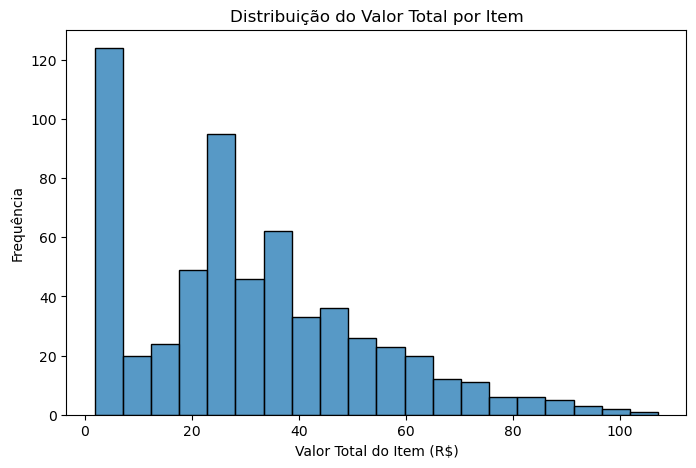

In [323]:
plt.figure(figsize=(8, 5))
sns.histplot(data=fato, x='TOTAL_ITEM', bins=20)

plt.title('Distribuição do Valor Total por Item')
plt.xlabel('Valor Total do Item (R$)')
plt.ylabel('Frequência')
plt.show()

Conforme observado nas análises anteriores, a maior concentração de ocorrências está associada a produtos de menor valor.

**Boxplot**

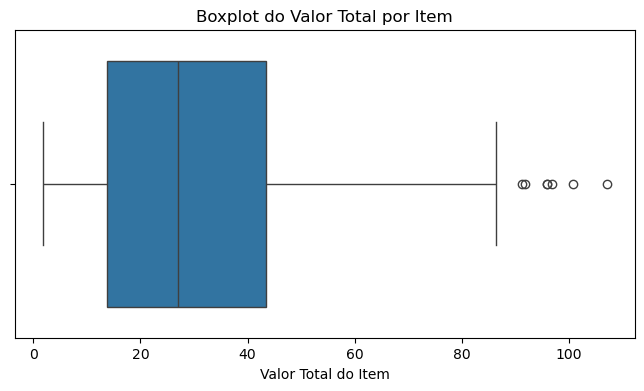

In [326]:
plt.figure(figsize=(8,4))
sns.boxplot(data=fato, x='TOTAL_ITEM')

plt.title('Boxplot do Valor Total por Item')
plt.xlabel('Valor Total do Item')
plt.show()

O gráfico revela assimetria positiva e alta variabilidade no valor total por item, com concentração dos dados em valores mais baixos.

**Dispersão**

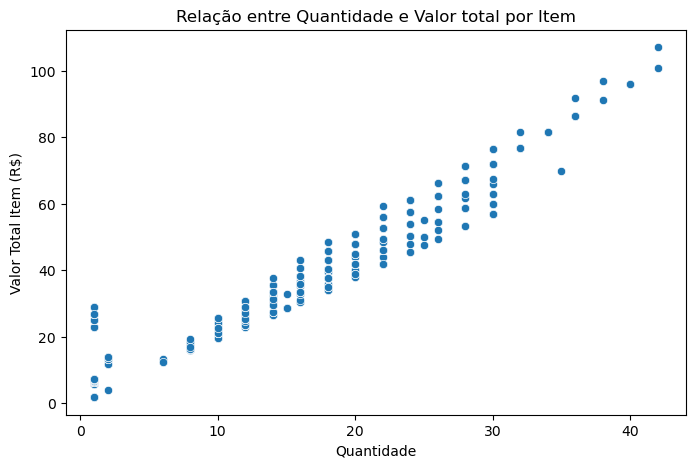

In [329]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=fato, x='QTD', y='TOTAL_ITEM')

plt.title('Relação entre Quantidade e Valor total por Item')
plt.xlabel('Quantidade')
plt.ylabel('Valor Total Item (R$)')
plt.show()

Observa-se relação positiva entre quantidade e valor total, com maior concentração de observações em faixas inferiores.

## 4. Análises direcionadas

### 4.1 Análise Vendas por Produto

In [333]:
qtd_venda_produto = (fato.groupby('NM_PRODUTO')
    .agg(QTD_VENDIDA = ('QTD', 'sum'))
    
).sort_values('QTD_VENDIDA', ascending=False)
qtd_venda_produto

,QTD_VENDIDA
NM_PRODUTO,
Chocolate,3260
Morango,2280
Napolitano,980
Creme,914
Limão,84
Uva,65
Manga,32
Abacaxi,22


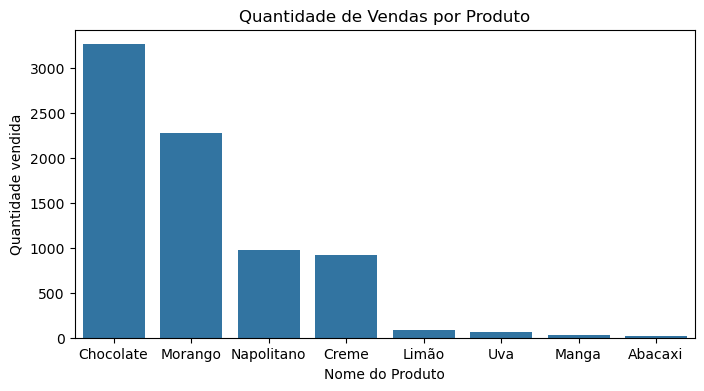

In [334]:
plt.figure(figsize=(8,4))
sns.barplot(data=qtd_venda_produto, x='NM_PRODUTO', y='QTD_VENDIDA')

plt.title('Quantidade de Vendas por Produto')
plt.xlabel('Nome do Produto')
plt.ylabel('Quantidade vendida')
plt.show()

Analisando a tabela em conjunto com o gráfico, fica evidente a dominância dos produtos Chocolate e Morango.

### 4.2 Análise Faturamento por Produto

In [337]:
faturamento_produto = (fato.groupby('NM_PRODUTO')
    .agg(FATURAMENTO = ('TOTAL_ITEM', 'sum'))
    .sort_values('FATURAMENTO', ascending=False)
)
faturamento_produto

,FATURAMENTO
NM_PRODUTO,
Chocolate,7654.7
Morango,4689.0
Napolitano,2428.8
Creme,2015.1
Manga,655.6
Limão,531.8
Abacaxi,410.4
Uva,380.9


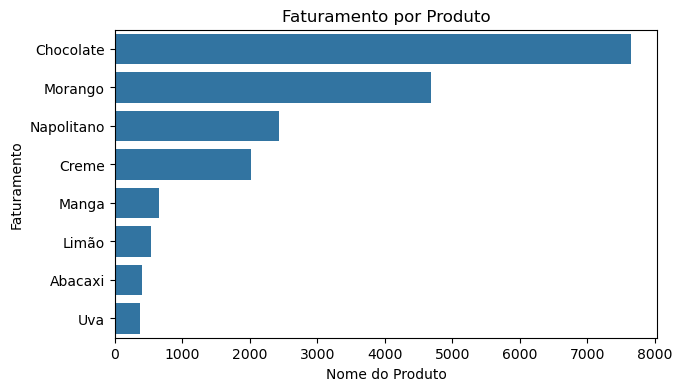

In [338]:
plt.figure(figsize=(7,4))
sns.barplot(data=faturamento_produto, 
            x= 'FATURAMENTO',
            y= faturamento_produto.index)

plt.title('Faturamento por Produto')
plt.xlabel('Nome do Produto')
plt.ylabel('Faturamento')
plt.show()

O gráfico evicencia a dominância, em termos de faturamento, dos produtos Chocolate e Morango.

### 4.3 Análise Ticket Medio por Produto

In [341]:
ticket_medio = (fato.groupby('NM_PRODUTO')
    .agg(FATURAMENTO = ('TOTAL_ITEM', 'sum'),
         QTD_PEDIDOS = ('ID_PEDIDO', 'nunique'))
).sort_values('FATURAMENTO', ascending=False)

ticket_medio['TICKET_MEDIO'] = (ticket_medio['FATURAMENTO'] / ticket_medio['QTD_PEDIDOS']).round(2)
ticket_medio

,FATURAMENTO,QTD_PEDIDOS,TICKET_MEDIO
NM_PRODUTO,,,
Chocolate,7654.7,151,50.69
Morango,4689.0,122,38.43
Napolitano,2428.8,68,35.72
Creme,2015.1,75,26.87
Manga,655.6,31,21.15
Limão,531.8,72,7.39
Abacaxi,410.4,22,18.65
Uva,380.9,62,6.14


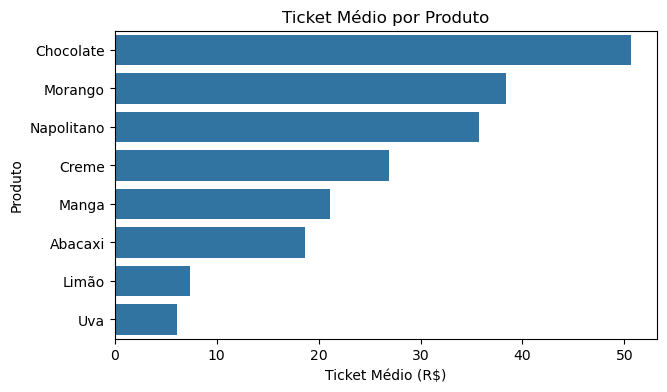

In [342]:
ticket_medio_ord = ticket_medio.sort_values('TICKET_MEDIO', ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(data=ticket_medio_ord, x='TICKET_MEDIO', y=ticket_medio_ord.index)

plt.title('Ticket Médio por Produto')
plt.xlabel('Ticket Médio (R$)')
plt.ylabel('Produto')
plt.show()

O gráfico evidencia que, embora o faturamento do produto Abacaxi seja baixo,  seu ticket médio  corresponde a  
quase metade do ticket médio do produto Chocolate.

### 4.4 Análise quantidade vendida por estado

In [345]:
faturamento_estado = (fato.groupby('ESTADO')
        .agg(QTD_VENDIDA = ('QTD', 'sum'), FATURAMENTO = ('TOTAL_ITEM', 'sum'))
        .sort_values('QTD_VENDIDA', ascending=False).head(5)
)
faturamento_estado

,QTD_VENDIDA,FATURAMENTO
ESTADO,,
BA,1037,2356.1
CE,1034,2500.2
MT,663,1469.5
ES,584,1547.6
AM,524,1160.4


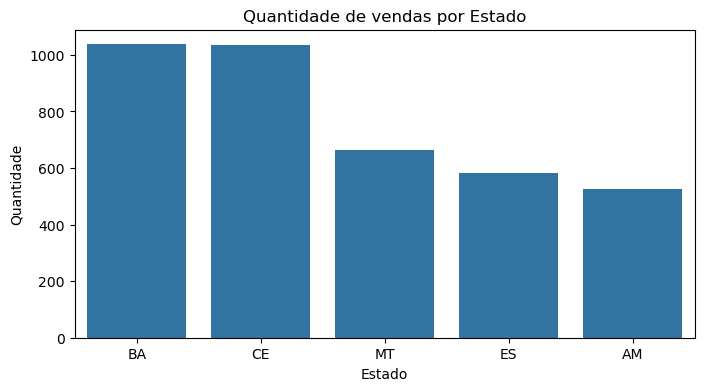

In [346]:
ordem_quantidade = faturamento_estado.sort_values('QTD_VENDIDA', ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(data=ordem_quantidade, x='ESTADO', y='QTD_VENDIDA')

plt.title('Quantidade de vendas por Estado')
plt.xlabel('Estado')
plt.ylabel('Quantidade')
plt.show()

A agregação por estado evidencia diferenças significativas no volume de vendas entre as regiões analisadas.

### 4.5 Análise de faturamento por estado

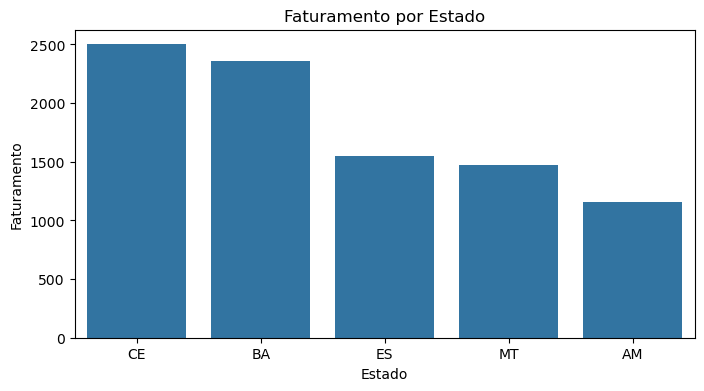

In [349]:
ordem_faturamento = faturamento_estado.sort_values('FATURAMENTO', ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(data=ordem_faturamento, x='ESTADO', y='FATURAMENTO')

plt.title('Faturamento por Estado')
plt.xlabel('Estado')
plt.ylabel('Faturamento')
plt.show()

Observa-se que, embora alguns estados apresentem maior quantidade de vendas, outros, mesmo com menor volume,  
registram faturamento superior.

### 4.6 Análise Ticket medio por Estado

In [352]:
ticket_medio_estado = (fato.groupby('ESTADO')
    .agg(FATURAMENTO = ('TOTAL_ITEM', 'sum'),
         QTD_PEDIDOS = ('ID_PEDIDO', 'nunique'))
)

ticket_medio_estado['TICKET_MEDIO'] = (ticket_medio_estado['FATURAMENTO'] / ticket_medio_estado['QTD_PEDIDOS']).round(2)
ticket_medio_estado.sort_values('TICKET_MEDIO', ascending=False).head(5)

,FATURAMENTO,QTD_PEDIDOS,TICKET_MEDIO
ESTADO,,,
PI,1118.9,18,62.16
AP,180.6,3,60.20
CE,2500.2,44,56.82
TO,485.8,10,48.58
MS,1006.7,21,47.94


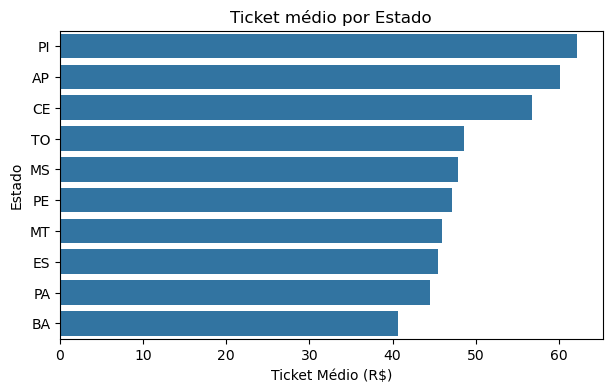

In [353]:
ticket_medio_estado_ord = ticket_medio_estado.sort_values('TICKET_MEDIO', ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(data=ticket_medio_estado_ord.head(10), x='TICKET_MEDIO', y=ticket_medio_estado_ord.head(10).index)

plt.title('Ticket médio por Estado')
plt.xlabel('Ticket Médio (R$)')
plt.ylabel('Estado')
plt.show()

## 5. Análise Temporal das Vendas

### 5.1 Faturamento ao longo do Tempo

* Preparando a base para Series Temporais

In [357]:
fato.head(2)

,ID_PEDIDO,DT_PEDIDO,ID_CLIENTE,ESTADO,ID_PRODUTO,NM_PRODUTO,ID_CATEG,QTD,VL_PRATICADO,TOTAL_ITEM
0,1,2023-01-03,1,BA,1,Chocolate,1,12,2.0,24.0
1,1,2023-01-03,1,BA,5,Limão,2,1,1.8,1.8


In [358]:
# Verificando tipo datetime
fato.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ID_PEDIDO     604 non-null    int64         
 1   DT_PEDIDO     604 non-null    datetime64[ns]
 2   ID_CLIENTE    604 non-null    int64         
 3   ESTADO        604 non-null    object        
 4   ID_PRODUTO    604 non-null    int64         
 5   NM_PRODUTO    604 non-null    object        
 6   ID_CATEG      604 non-null    int64         
 7   QTD           604 non-null    int64         
 8   VL_PRATICADO  604 non-null    float64       
 9   TOTAL_ITEM    604 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(5), object(2)
memory usage: 47.3+ KB


In [359]:
# Agrupando data do pedido e vendas totais
temps = (fato.groupby('DT_PEDIDO', as_index=True)
    .agg(TOTAL_DIA=('TOTAL_ITEM', 'sum'))
    .sort_index()
)
temps.head(2)

,TOTAL_DIA
DT_PEDIDO,
2023-01-03,60.0
2023-01-04,53.5


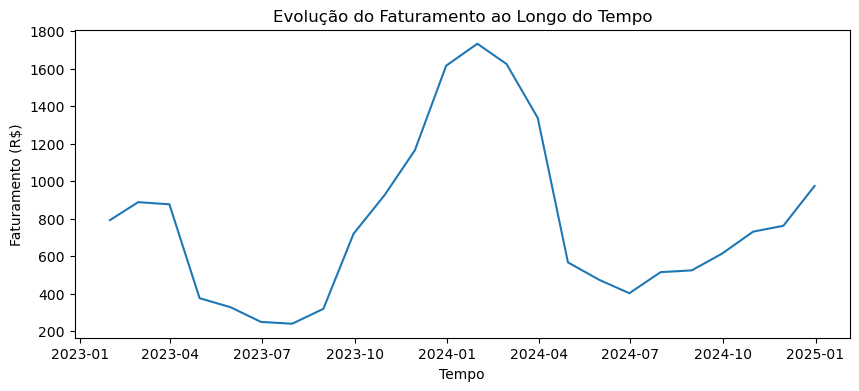

In [360]:
serie_mensal = (temps.resample('ME')['TOTAL_DIA'].sum())

plt.figure(figsize=(10,4))
plt.plot(serie_mensal.index, serie_mensal.values)

plt.title('Evolução do Faturamento ao Longo do Tempo')
plt.xlabel('Tempo')
plt.ylabel('Faturamento (R$)')
plt.show()

Ao analisar o gráfico, observa-se uma queda significativa no faturamento no mês de julho.

### 5.2 Comparando faturamentos 2023 x 2024

In [363]:
# Separando 2023 de 2024

historico_2023 = temps.loc['2023-01-01':'2023-12-31']
mensal_2023 = (historico_2023.resample('ME')['TOTAL_DIA'].sum())

historico_2024 = temps.loc['2024-01-01':'2024-12-31']
mensal_2024 = (historico_2024.resample('ME')['TOTAL_DIA'].sum())

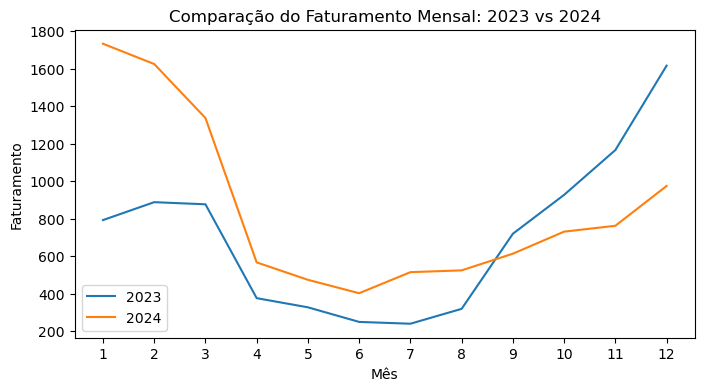

In [364]:
df_2023 = mensal_2023.reset_index()
df_2023['MES'] = df_2023['DT_PEDIDO'].dt.month

df_2024 = mensal_2024.reset_index()
df_2024['MES'] = df_2024['DT_PEDIDO'].dt.month

plt.figure(figsize=(8,4))

sns.lineplot(data=df_2023, x='MES', y='TOTAL_DIA', label='2023')
sns.lineplot(data=df_2024, x='MES', y='TOTAL_DIA', label='2024')

plt.title('Comparação do Faturamento Mensal: 2023 vs 2024')
plt.xlabel('Mês')
plt.ylabel('Faturamento')
plt.xticks(range(1,13))
plt.show()

Observa-se que, ao longo do período analisado, ambos os anos apresentam uma queda de faturamento no meio do ano, seguida por recuperação nos meses posteriores.

Em julho de 2024, nota-se uma melhora significativa no faturamento em comparação ao mesmo período de 2023, indicando uma recuperação mais rápida no segundo ano.

Apesar de 2024 apresentar uma variação negativa menos acentuada em relação a 2023, o crescimento posterior também foi mais moderado, sugerindo um comportamento de recuperação mais estável, porém menos intensa.

### 5.3 Faturamento do Top 2 Estados

In [367]:
# Criar colunas de apoio
fato['MES_ANO'] = fato['DT_PEDIDO'].dt.to_period('M').dt.to_timestamp()

In [368]:
faturamento_estado = (fato.groupby('ESTADO')
    .agg(FATURAMENTO = ('TOTAL_ITEM', 'sum'))
    .reset_index()
    .sort_values('FATURAMENTO', ascending=False)
)
faturamento_estado.head(2)

,ESTADO,FATURAMENTO
4,CE,2500.2
3,BA,2356.1


In [369]:
# Top 2 Estados
top2 = faturamento_estado.head(2)['ESTADO'].tolist()
top2

['CE', 'BA']

In [370]:
# Agrupamento mensal apenas dos Top 2 estados
faturamento_top2 = (
    fato[fato['ESTADO'].isin(top2)]
    .groupby(['MES_ANO', 'ESTADO'], as_index=False)['TOTAL_ITEM']
    .sum()
    .rename(columns={'TOTAL_ITEM': 'FATURAMENTO'})
)
faturamento_top2.head(2)

,MES_ANO,ESTADO,FATURAMENTO
0,2023-01-01,BA,232.3
1,2023-01-01,CE,113.0


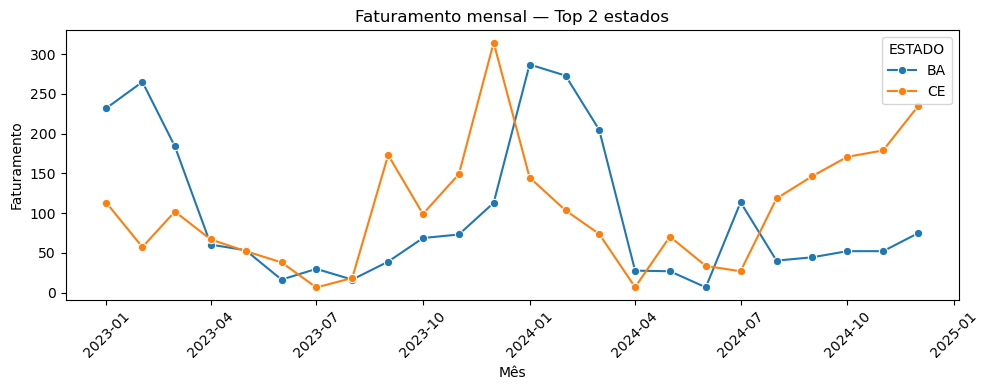

In [371]:
plt.figure(figsize=(10,4))
sns.lineplot(
    data=faturamento_top2,
    x='MES_ANO',
    y='FATURAMENTO',
    hue='ESTADO',
    marker='o'
)
plt.title('Faturamento mensal — Top 2 estados')
plt.xlabel('Mês')
plt.ylabel('Faturamento')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observa-se que ambos os estados apresentam sazonalidade ao longo do ano, com quedas recorrentes no meio do período e recuperação posterior. Em 2024, essa retração foi menos acentuada do que em 2023, indicando maior estabilidade do faturamento. Destaca-se o Ceará, que apresentou crescimento consistente no segundo semestre de 2024, superando a Bahia e sugerindo um desempenho comercial mais sólido no período analisado.

Conclusão da Análise Exploratória de Dados

Nesta etapa de Análise Exploratória de Dados, foi realizada uma investigação inicial sobre o comportamento das vendas do sistema Deep Ice Cream, com foco em compreender padrões, consistência dos dados e possíveis direcionamentos analíticos futuros.

A partir da construção da tabela fato, foi possível consolidar informações de pedidos, produtos, clientes, estados e valores financeiros em uma única visão analítica, garantindo coerência temporal e consistência nos relacionamentos entre as tabelas.

As análises descritivas indicaram que:

* O faturamento apresenta assimetria positiva, com concentração de vendas em valores mais baixos e poucos pedidos de alto valor.

* Existe variação relevante entre estados, com alguns se destacando de forma consistente ao longo do período analisado.

* A análise temporal revelou comportamentos sazonais, incluindo períodos de queda seguidos de recuperação, além de diferenças claras entre os anos de 2023 e 2024.

* Apesar de oscilações ao longo do tempo, o padrão observado faz sentido do ponto de vista de negócio, indicando maturidade gradual do faturamento em determinados mercados.

Além disso, a etapa de EDA permitiu:

* Validar tipos de dados e formatos, especialmente datas e valores monetários;

* Identificar possíveis inconsistências e tratá-las antes de análises mais avançadas;

* Levantar perguntas relevantes de negócio, como o desempenho comparativo entre estados ao longo do tempo e a concentração de faturamento por produto.

